# Configuration

In [3]:
from pathlib import Path
import sys

# Notebook-safe project path. In notebooks, __file__ is not available.
cwd = Path.cwd()
PROJECT_DIR = cwd.parent if cwd.name in {"pipeline", "notebooks"} else cwd
HELPER_DIR = PROJECT_DIR / "helper"

if str(HELPER_DIR) not in sys.path:
    sys.path.append(str(HELPER_DIR))

DATASET_PATH = PROJECT_DIR / "dataset" / "posture_data.csv"
REPORT_DIR = PROJECT_DIR / "reports"
MODEL_DIR = PROJECT_DIR / "models"

SENSOR1_COLS = ["Ax1", "Ay1", "Az1"]
SENSOR2_COLS = ["Ax2", "Ay2", "Az2"]
ACC_COLS = SENSOR1_COLS + SENSOR2_COLS
LABEL_COL = "label"

# For 10 Hz data, set SAMPLE_RATE_HZ = 10 and WINDOW_SIZE = 10.
SAMPLE_RATE_HZ = 10
LOWPASS_CUTOFF_HZ = 4.5
WINDOW_SIZE = 10
WINDOW_STEP = 10

LABEL_NAMES = {
    0: "Standing",
    1: "Sitting",
    2: "Sleeping",
    3: "Running",
    4: "Forward bending",
    5: "Backward bending",
}

dataset_path = DATASET_PATH
dataset_path

WindowsPath('d:/MonHoc_HK6/Do_an_2/Do_An/Detect_posture/dataset/posture_data.csv')

# EDA dataset posture IMU

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.signal import butter, filtfilt

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

def validate_dataset(df: pd.DataFrame) -> dict:
    # Check required columns and basic dataset health.
    required_cols = ACC_COLS + [LABEL_COL]
    missing_cols = [col for col in required_cols if col not in df.columns]

    numeric_df = df[[col for col in ACC_COLS if col in df.columns]]
    missing_values = df.isna().sum().to_dict()
    duplicated_rows = int(df.duplicated().sum())
    label_counts = df[LABEL_COL].value_counts().sort_index().to_dict() if LABEL_COL in df else {}

    outlier_summary = {}
    for col in numeric_df.columns:
        # Use the IQR rule to estimate possible outliers per axis.
        q1 = numeric_df[col].quantile(0.25)
        q3 = numeric_df[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        mask = (numeric_df[col] < lower) | (numeric_df[col] > upper)
        outlier_summary[col] = {
            "count": int(mask.sum()),
            "ratio": float(mask.mean()),
            "lower": float(lower),
            "upper": float(upper),
        }

    return {
        "n_rows": int(len(df)),
        "n_cols": int(df.shape[1]),
        "missing_required_cols": missing_cols,
        "missing_values": missing_values,
        "duplicated_rows": duplicated_rows,
        "n_classes": int(df[LABEL_COL].nunique()) if LABEL_COL in df else 0,
        "label_counts": label_counts,
        "outliers_iqr": outlier_summary,
    }

from pathlib import Path

import numpy as np
import pandas as pd
from scipy.signal import butter, filtfilt

EPS = 1e-8

def clean_dataset(df: pd.DataFrame, outlier_mode: str = "keep") -> pd.DataFrame:
    # Keep only valid numeric accelerometer values and integer labels.
    clean = df.copy()
    clean = clean.dropna(subset=ACC_COLS + [LABEL_COL])

    for col in ACC_COLS:
        clean[col] = pd.to_numeric(clean[col], errors="coerce")
    clean[LABEL_COL] = pd.to_numeric(clean[LABEL_COL], errors="coerce")
    clean = clean.dropna(subset=ACC_COLS + [LABEL_COL])
    clean[LABEL_COL] = clean[LABEL_COL].astype(int)

    if outlier_mode == "clip":
        # Clip outliers to the IQR boundary instead of removing rows.
        for col in ACC_COLS:
            q1 = clean[col].quantile(0.25)
            q3 = clean[col].quantile(0.75)
            iqr = q3 - q1
            clean[col] = clean[col].clip(q1 - 1.5 * iqr, q3 + 1.5 * iqr)
    elif outlier_mode == "drop":
        # Drop rows that are outside the IQR boundary on any axis.
        mask = np.ones(len(clean), dtype=bool)
        for col in ACC_COLS:
            q1 = clean[col].quantile(0.25)
            q3 = clean[col].quantile(0.75)
            iqr = q3 - q1
            mask &= clean[col].between(q1 - 1.5 * iqr, q3 + 1.5 * iqr)
        clean = clean.loc[mask]

    return clean.reset_index(drop=True)

def apply_lowpass(
    df: pd.DataFrame,
    fs: float = SAMPLE_RATE_HZ,
    cutoff: float = LOWPASS_CUTOFF_HZ,
    order: int = 2,
) -> pd.DataFrame:
    # Apply a light low-pass filter to reduce high-frequency noise.
    filtered = df.copy()
    filtered[ACC_COLS] = filtered[ACC_COLS].astype(float)
    nyquist = 0.5 * fs
    normalized_cutoff = cutoff / nyquist
    if not 0 < normalized_cutoff < 1:
        raise ValueError("cutoff must be lower than Nyquist frequency")

    b, a = butter(order, normalized_cutoff, btype="low")
    for label, group in filtered.groupby(LABEL_COL, sort=False):
        # Filter each posture block separately to avoid mixing labels.
        idx = group.index
        if len(group) <= max(len(a), len(b)) * 3:
            continue
        filtered.loc[idx, ACC_COLS] = filtfilt(b, a, group[ACC_COLS].to_numpy(), axis=0)
    return filtered


def add_instant_features(df: pd.DataFrame) -> pd.DataFrame:
    # Build per-sample features before aggregating them into windows.
    out = df.copy()
    for prefix, cols in [("s1", SENSOR1_COLS), ("s2", SENSOR2_COLS)]:
        ax, ay, az = [out[col] for col in cols]
        # Magnitude and normalized axes describe the gravity direction.
        mag = np.sqrt(ax**2 + ay**2 + az**2)
        out[f"{prefix}_acc_mag"] = mag
        out[f"{prefix}_Ax_norm"] = ax / (mag + EPS)
        out[f"{prefix}_Ay_norm"] = ay / (mag + EPS)
        out[f"{prefix}_Az_norm"] = az / (mag + EPS)
        # Roll and pitch approximate sensor orientation from acceleration.
        out[f"{prefix}_roll"] = np.arctan2(ay, az)
        out[f"{prefix}_pitch"] = np.arctan2(-ax, np.sqrt(ay**2 + az**2))
        out[f"{prefix}_abs_Ax_Ay"] = np.abs(ax - ay)
        out[f"{prefix}_abs_Ay_Az"] = np.abs(ay - az)
        out[f"{prefix}_abs_Az_Ax"] = np.abs(az - ax)

    v1 = out[SENSOR1_COLS].to_numpy()
    v2 = out[SENSOR2_COLS].to_numpy()
    # Angle between the two sensor vectors captures body segment posture.
    dot = np.sum(v1 * v2, axis=1)
    mag1 = out["s1_acc_mag"].to_numpy()
    mag2 = out["s2_acc_mag"].to_numpy()
    cos_angle = dot / (mag1 * mag2 + EPS)
    out["sensor_angle"] = np.arccos(np.clip(cos_angle, -1.0, 1.0))

    out["pitch_diff"] = out["s1_pitch"] - out["s2_pitch"]
    out["roll_diff"] = out["s1_roll"] - out["s2_roll"]
    out["acc_mag_diff"] = out["s1_acc_mag"] - out["s2_acc_mag"]

    for prefix, cols in [("s1", SENSOR1_COLS), ("s2", SENSOR2_COLS)]:
        # Jerk measures how much acceleration changes between samples.
        jerk = out.groupby(LABEL_COL, sort=False)[cols].diff().fillna(0.0)
        out[f"{prefix}_jerk_mag"] = np.sqrt(np.sum(jerk.to_numpy() ** 2, axis=1))

    return out


def _window_label(labels: pd.Series) -> int | None:
    # Use the only label in a clean window; skip mixed-label windows.
    modes = labels.mode()
    if len(modes) != 1:
        return None
    return int(modes.iloc[0])


def extract_window_features(
    df: pd.DataFrame,
    window_size: int = WINDOW_SIZE,
    step: int = WINDOW_STEP,
) -> pd.DataFrame:
    # Convert consecutive samples into one feature row per time window.
    enriched = add_instant_features(df)
    feature_cols = [col for col in enriched.columns if col != LABEL_COL]
    rows = []

    for label, group in enriched.groupby(LABEL_COL, sort=False):
        group = group.reset_index(drop=True)
        for start in range(0, len(group) - window_size + 1, step):
            window = group.iloc[start : start + window_size]
            window_label = _window_label(window[LABEL_COL])
            if window_label is None:
                continue

            row = {LABEL_COL: window_label}
            for col in feature_cols:
                # Basic window statistics work well for Logistic Regression.
                values = window[col].to_numpy(dtype=float)
                row[f"{col}_mean"] = float(np.mean(values))
                row[f"{col}_std"] = float(np.std(values, ddof=0))
                row[f"{col}_min"] = float(np.min(values))
                row[f"{col}_max"] = float(np.max(values))
                row[f"{col}_range"] = float(np.max(values) - np.min(values))

            # Keep extra mean/std features requested for orientation signals.
            for col in [
                "s1_Ax_norm",
                "s1_Ay_norm",
                "s1_Az_norm",
                "s2_Ax_norm",
                "s2_Ay_norm",
                "s2_Az_norm",
                "s1_roll",
                "s1_pitch",
                "s2_roll",
                "s2_pitch",
                "pitch_diff",
                "roll_diff",
            ]:
                values = window[col].to_numpy(dtype=float)
                row[f"{col}_mean_only"] = float(np.mean(values))
                row[f"{col}_std_only"] = float(np.std(values, ddof=0))

            for prefix in ["s1", "s2"]:
                # Jerk uses mean/std/max to summarize motion intensity.
                jerk = window[f"{prefix}_jerk_mag"].to_numpy(dtype=float)
                row[f"{prefix}_jerk_mag_mean_custom"] = float(np.mean(jerk))
                row[f"{prefix}_jerk_mag_std_custom"] = float(np.std(jerk, ddof=0))
                row[f"{prefix}_jerk_mag_max_custom"] = float(np.max(jerk))

            rows.append(row)

    return pd.DataFrame(rows)

In [5]:
df = pd.read_csv(dataset_path)
if "index" in df.columns:
    df = df.drop(columns=["index"])

report = validate_dataset(df)

print('Shape:', df.shape)
print('Columns:', list(df.columns))
print('Missing required cols:', report['missing_required_cols'])
print('Duplicated rows:', report['duplicated_rows'])
print('Number of classes:', report['n_classes'])

display(df.head())
display(df.describe())


Shape: (45599, 7)
Columns: ['Ax1', 'Ay1', 'Az1', 'Ax2', 'Ay2', 'Az2', 'label']
Missing required cols: []
Duplicated rows: 0
Number of classes: 6


,Ax1,Ay1,Az1,Ax2,Ay2,Az2,label
0,-2336,11380,-84,77,74,152,0
1,-2372,11372,-28,69,86,174,0
2,-2316,11456,-24,76,22,157,0
3,-2496,11436,-20,64,49,190,0
4,-2528,11364,-140,60,56,199,0


,Ax1,Ay1,Az1,Ax2,Ay2,Az2,label
count,45599.000000,45599.000000,45599.000000,45599.000000,45599.000000,45599.000000,45599.000000
mean,11212.490537,3101.037194,-217.705213,452.749731,146.591153,814.477883,2.447883
std,7389.253575,9613.014285,3808.885594,5020.278710,1986.918870,454.113294,1.744163
min,-32668.000000,-32768.000000,-28904.000000,-32753.000000,-18052.000000,0.000000,0.000000
25%,3800.000000,-4476.000000,-216.000000,-110.000000,-37.000000,430.000000,1.000000
50%,15404.000000,-552.000000,-136.000000,62.000000,55.000000,713.000000,2.000000
75%,16188.000000,12752.000000,-56.000000,110.000000,111.000000,1206.000000,4.000000
max,32767.000000,32767.000000,32580.000000,32763.000000,27198.000000,1982.000000,5.000000


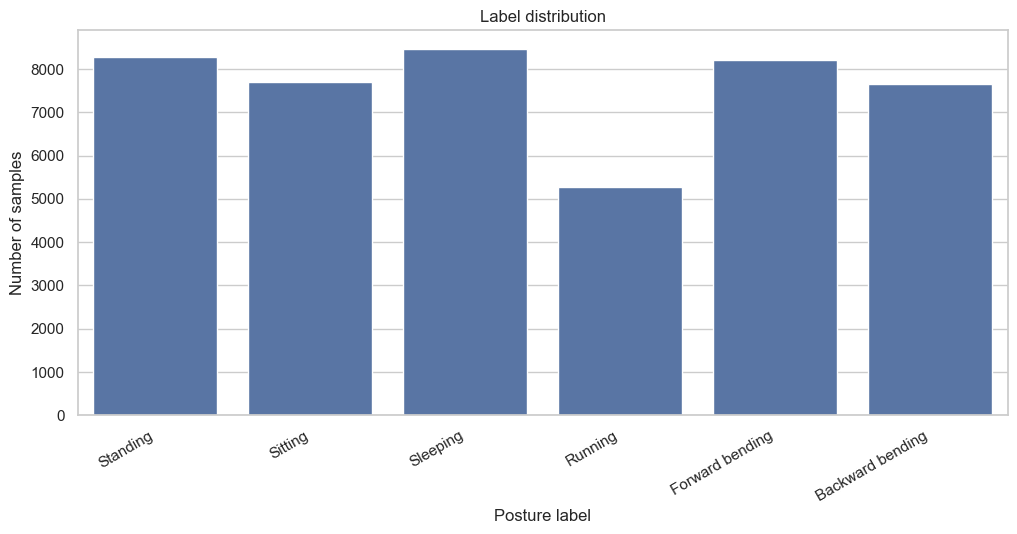

,label,name,count,ratio
0,0,Standing,8274,0.181451
1,1,Sitting,7706,0.168995
2,2,Sleeping,8472,0.185794
3,3,Running,5278,0.115748
4,4,Forward bending,8208,0.180004
5,5,Backward bending,7661,0.168008


In [6]:
label_counts = df[LABEL_COL].astype(int).value_counts().sort_index()
label_names = [LABEL_NAMES.get(int(label), str(label)) for label in label_counts.index]

ax = sns.barplot(x=label_names, y=label_counts.values)
ax.set_title('Label distribution')
ax.set_xlabel('Posture label')
ax.set_ylabel('Number of samples')
plt.xticks(rotation=30, ha='right')
plt.show()

display(pd.DataFrame({'label': label_counts.index, 'name': label_names, 'count': label_counts.values, 'ratio': label_counts.values / len(df)}))

## Missing values and outlier

missing    0
dtype: int64

,feature,count,ratio,lower,upper
2,Az1,6285,0.137832,-456.0,184.0
4,Ay2,6046,0.132591,-259.0,333.0
3,Ax2,6036,0.132371,-440.0,440.0
0,Ax1,39,0.000855,-14782.0,34770.0
1,Ay1,15,0.000329,-30318.0,38594.0
5,Az2,0,0.000000,-734.0,2370.0


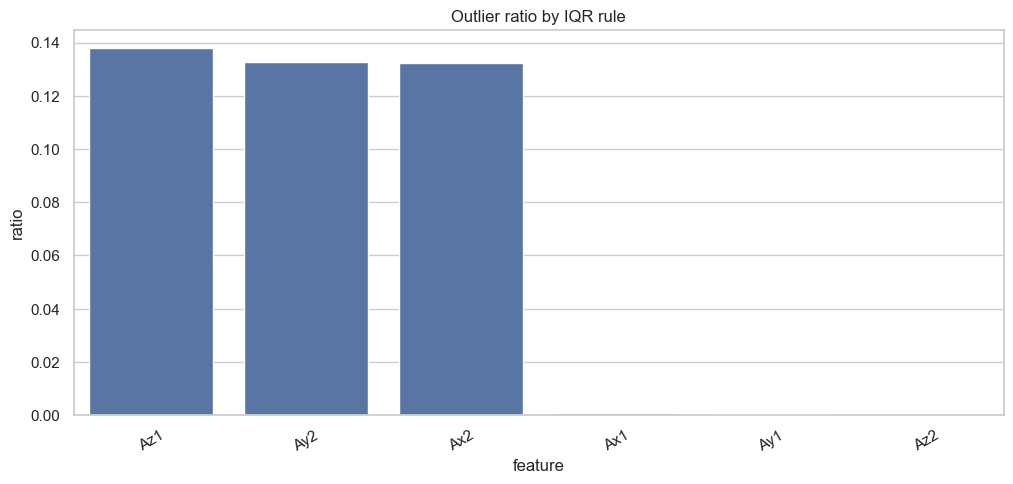

In [7]:
missing = df.isna().sum().sort_values(ascending=False)
display(missing[missing > 0] if (missing > 0).any() else pd.Series({'missing': 0}))

outlier_rows = []
for col, values in report['outliers_iqr'].items():
    outlier_rows.append({'feature': col, **values})
outlier_df = pd.DataFrame(outlier_rows).sort_values('ratio', ascending=False)
display(outlier_df)

sns.barplot(data=outlier_df, x='feature', y='ratio')
plt.title('Outlier ratio by IQR rule')
plt.xticks(rotation=30)
plt.show()

## Phan tich don bien

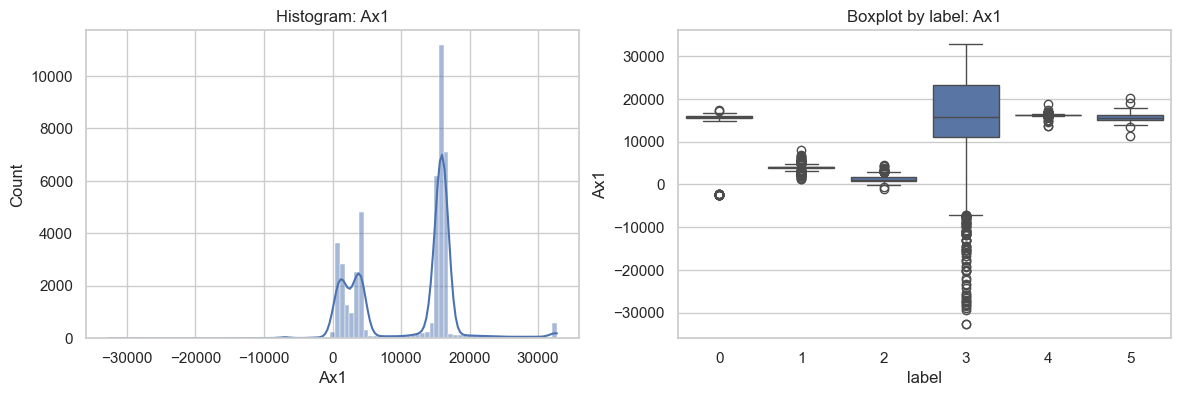

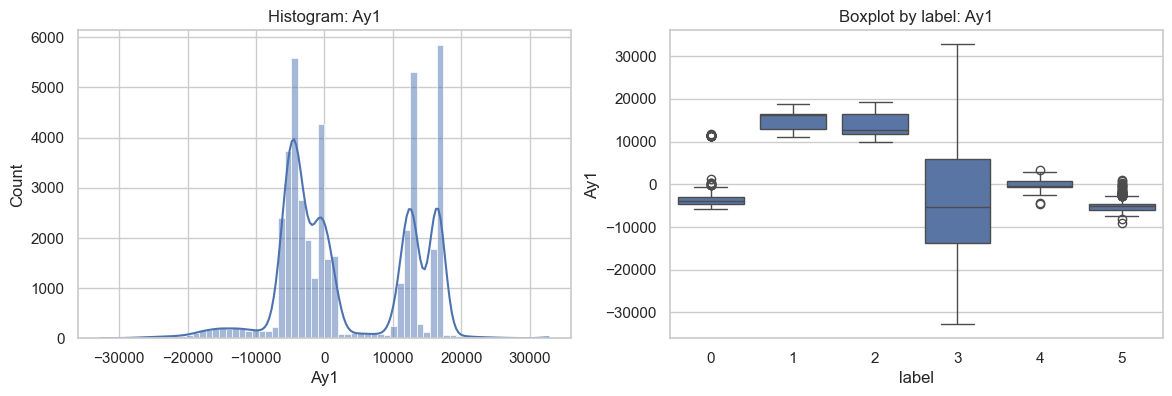

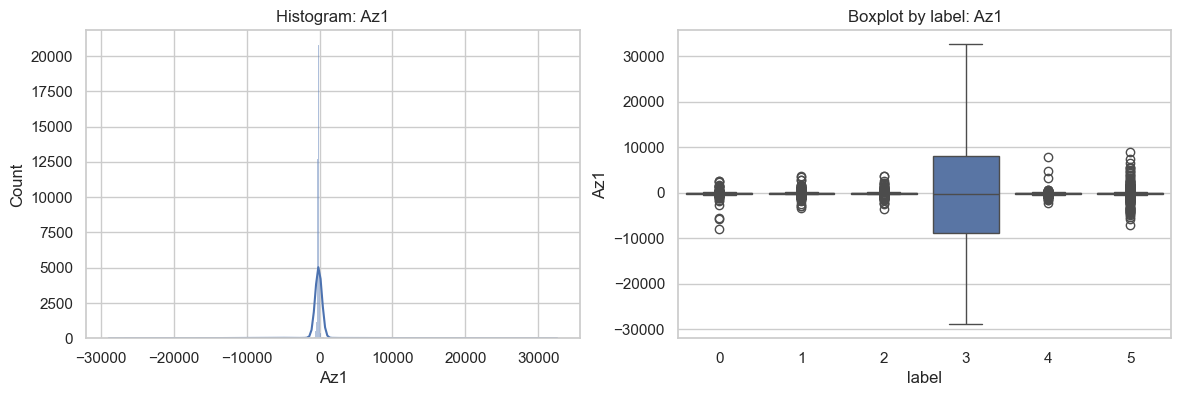

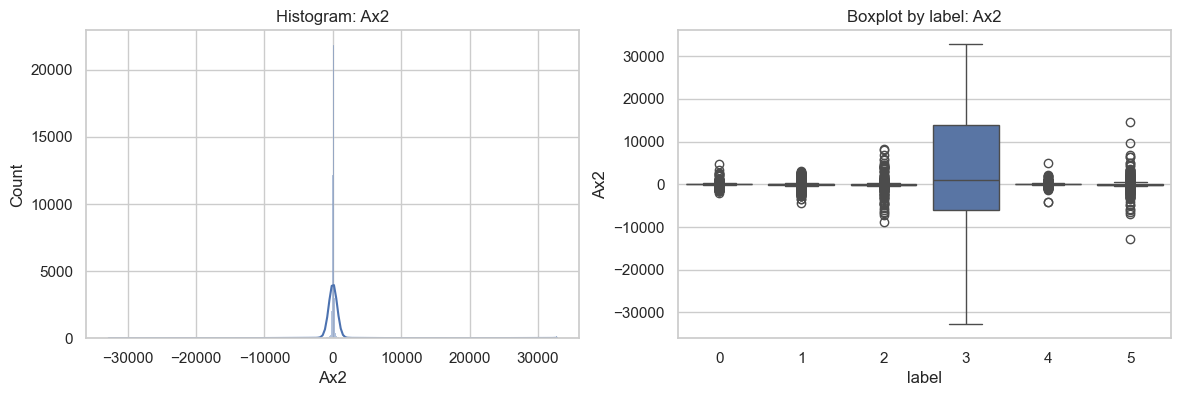

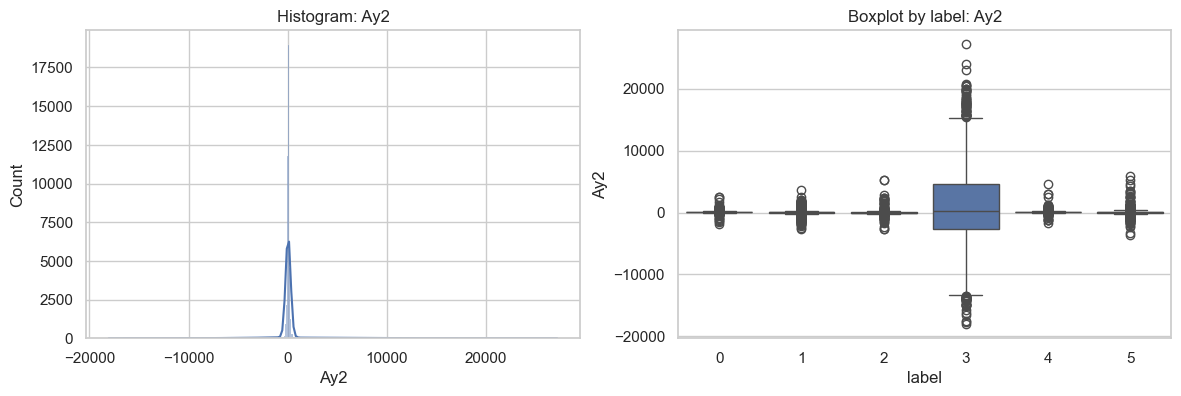

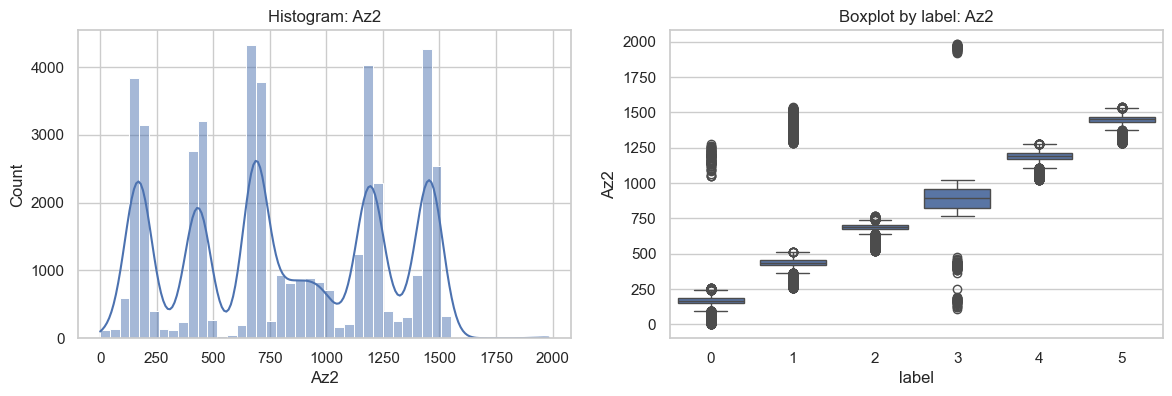

In [8]:
clean = clean_dataset(df)

for col in ACC_COLS:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    sns.histplot(clean[col], kde=True, ax=axes[0])
    axes[0].set_title(f'Histogram: {col}')
    sns.boxplot(data=clean, x=LABEL_COL, y=col, ax=axes[1])
    axes[1].set_title(f'Boxplot by label: {col}')
    plt.show()

## Phan tich da bien

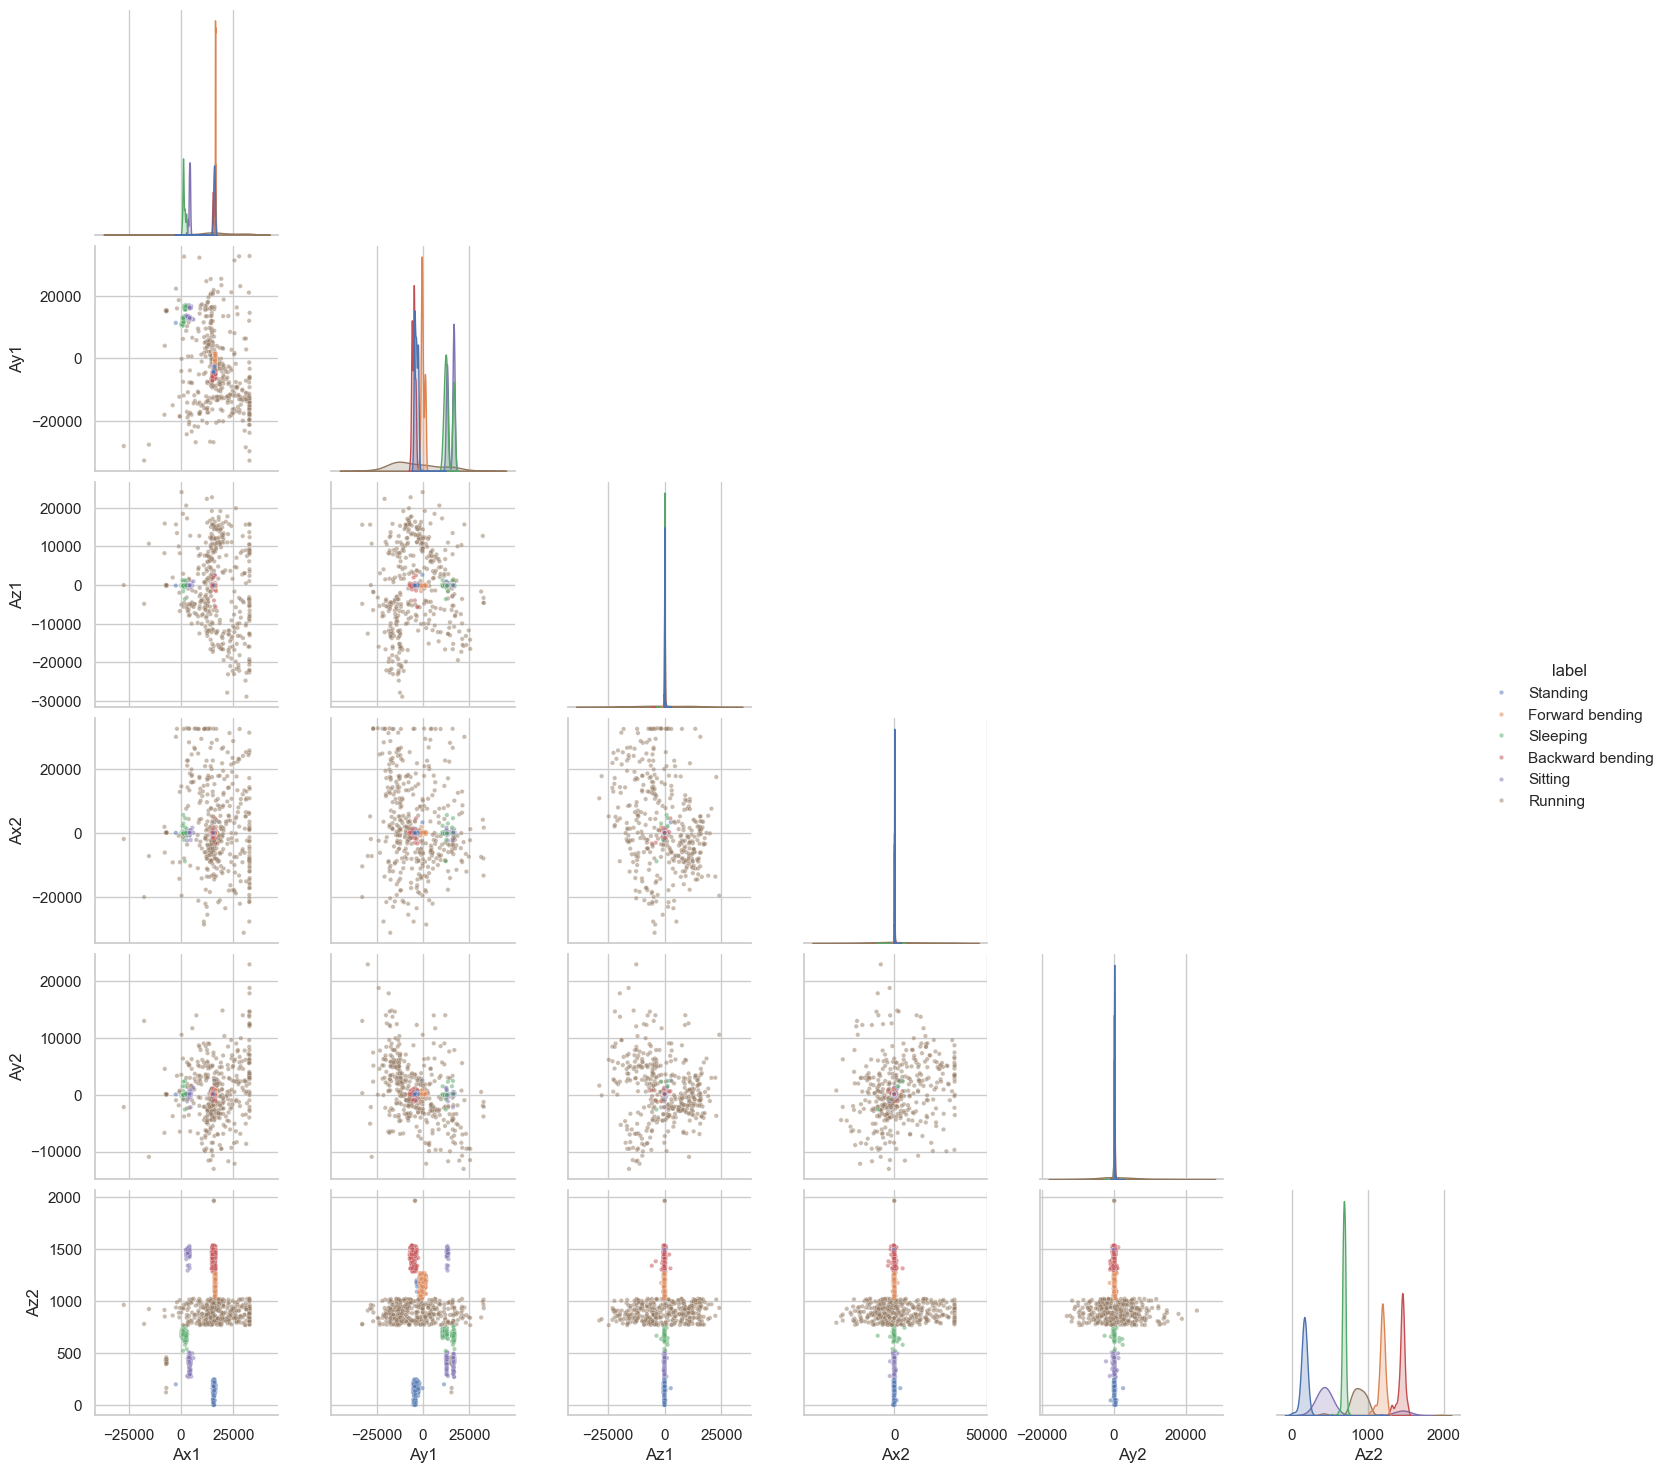

In [9]:
sample_df = clean.sample(min(3000, len(clean)), random_state=42).copy()
sample_df[LABEL_COL] = sample_df[LABEL_COL].astype(int).map(LABEL_NAMES).fillna(sample_df[LABEL_COL].astype(str))

sns.pairplot(sample_df[ACC_COLS + [LABEL_COL]], hue=LABEL_COL, corner=True, plot_kws={'s': 10, 'alpha': 0.5})
plt.show()

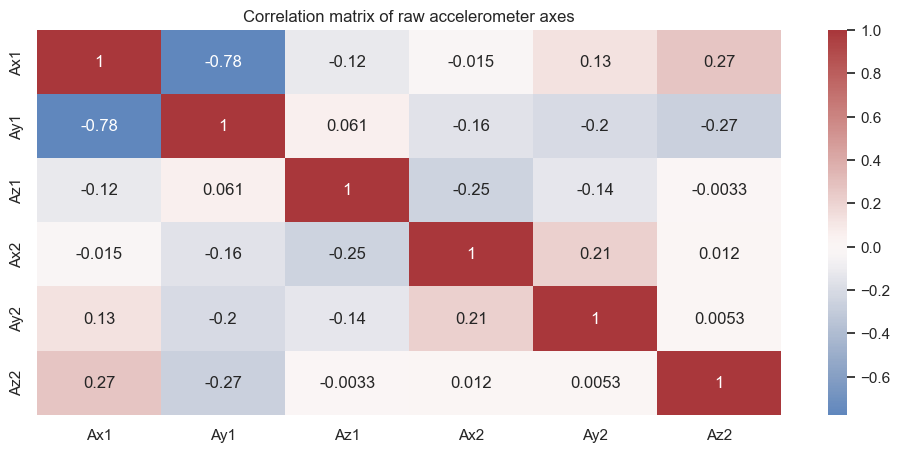

In [10]:
corr = clean[ACC_COLS].corr()
sns.heatmap(corr, annot=True, cmap='vlag', center=0)
plt.title('Correlation matrix of raw accelerometer axes')
plt.show()

## Feature tuc thoi: magnitude, norm, roll, pitch, angle giua hai sensor

,s1_acc_mag,s2_acc_mag,acc_mag_diff,s1_roll,s1_pitch,s2_roll,s2_pitch,pitch_diff,roll_diff,sensor_angle,label
0,11617.588046,185.765982,11431.822064,1.578178,0.202455,0.453066,-0.427393,0.629848,1.125112,1.265115,0
1,11616.778900,205.992718,11410.786181,1.573259,0.205634,0.459039,-0.341566,0.547200,1.114219,1.225727,0
2,11687.787130,175.809556,11511.977574,1.572891,0.199476,0.139221,-0.447026,0.646502,1.433670,1.535629,0
3,11705.234385,206.390407,11498.843978,1.572545,0.214888,0.252395,-0.315290,0.530178,1.320150,1.405792,0
4,11642.632005,215.260308,11427.371697,1.583115,0.218876,0.274313,-0.282474,0.501350,1.308802,1.387486,0


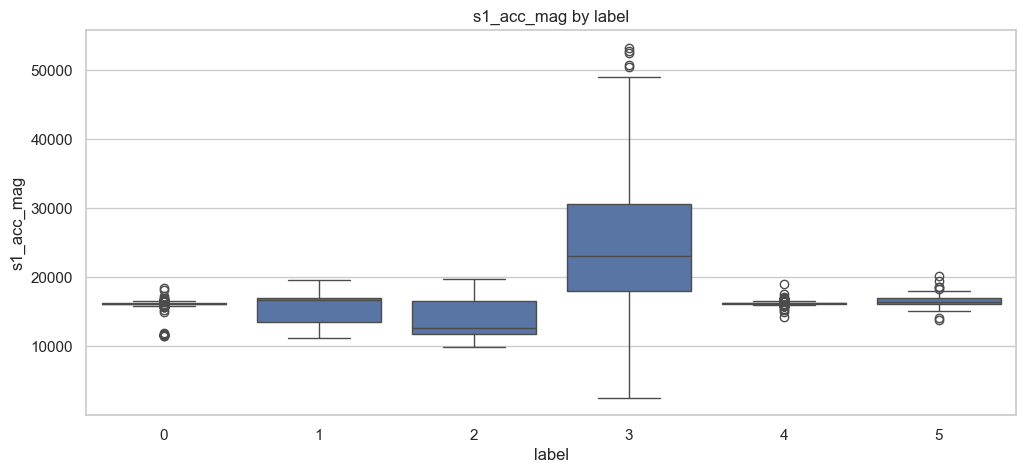

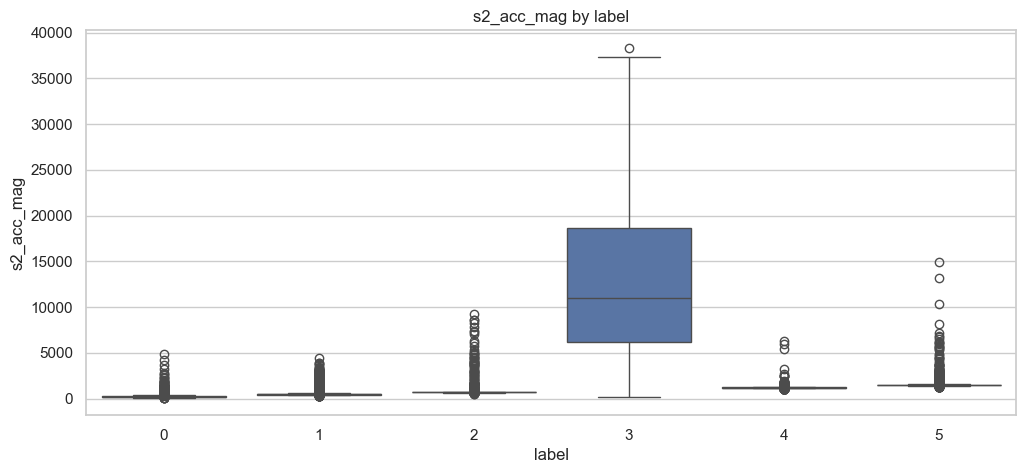

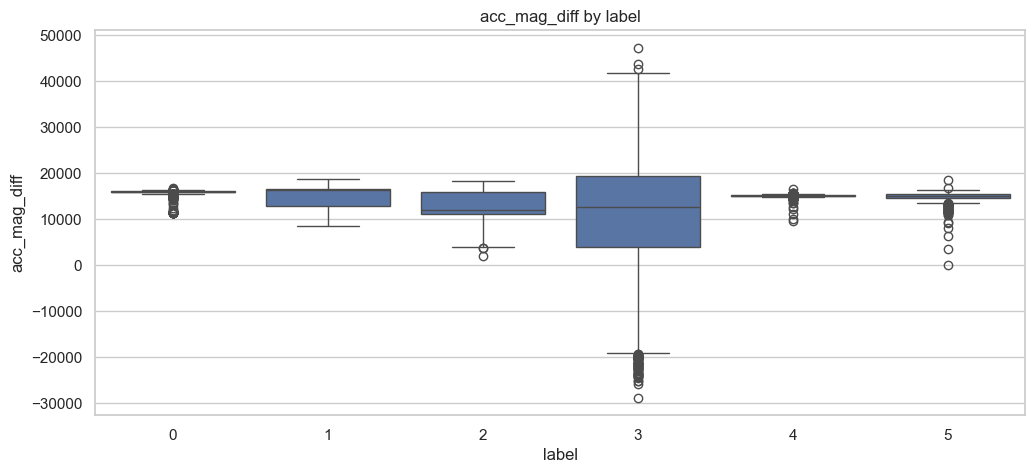

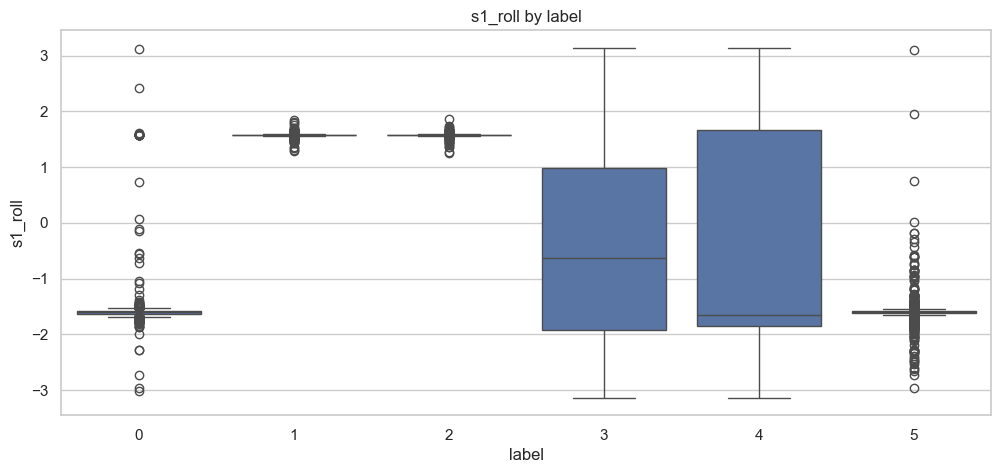

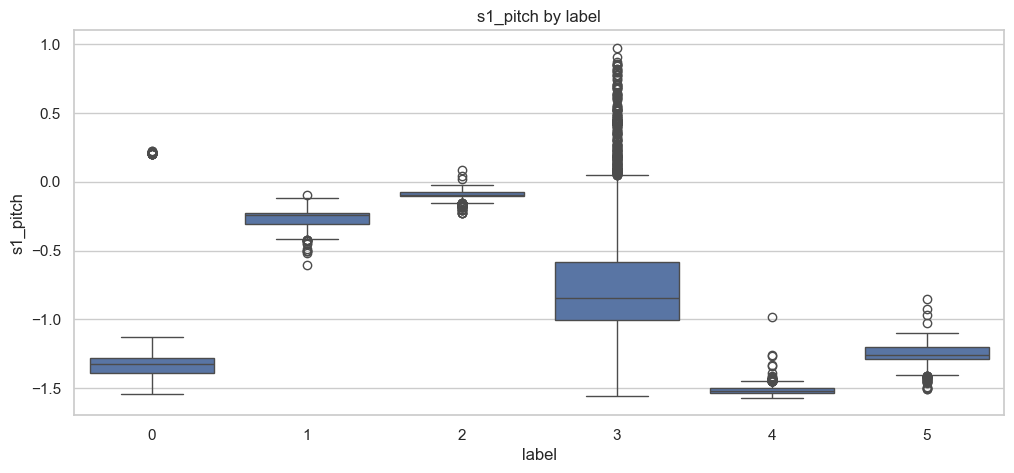

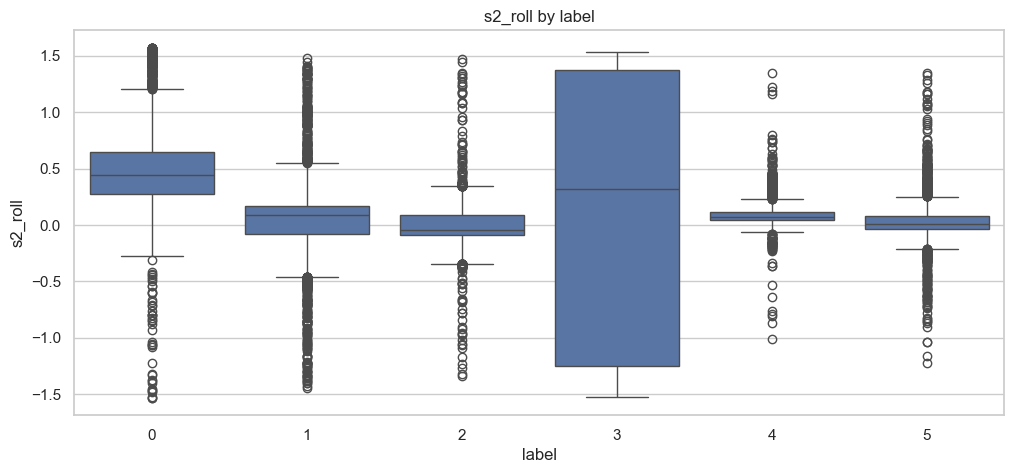

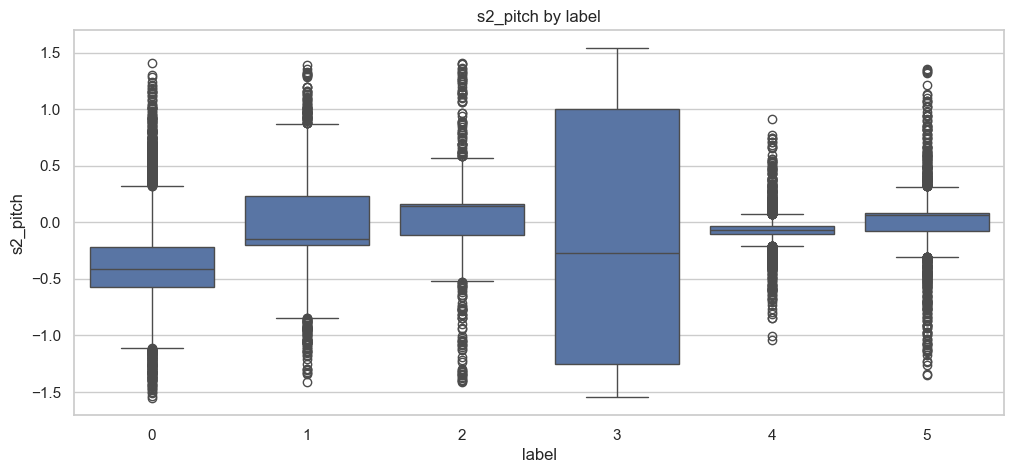

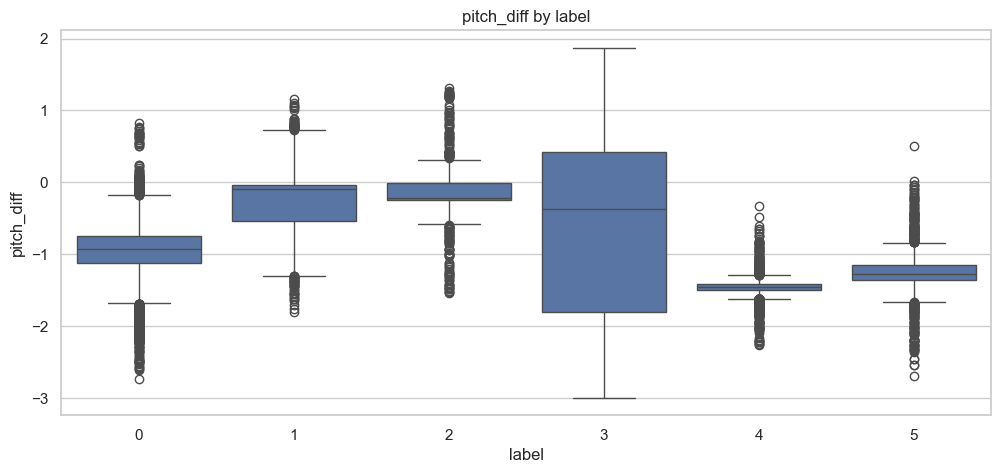

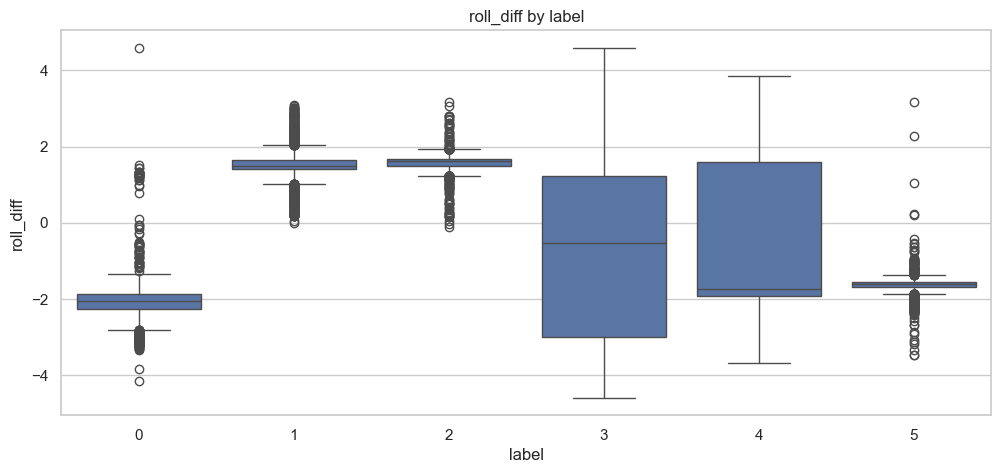

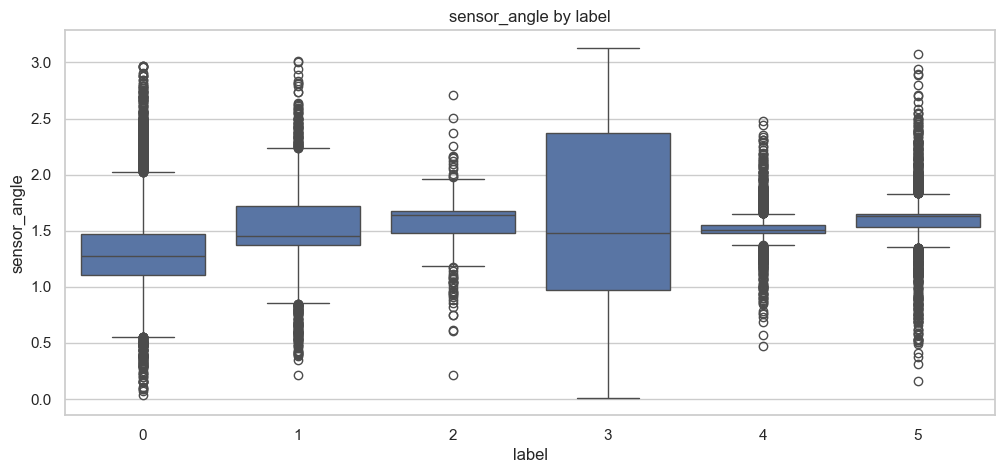

In [11]:
instant = add_instant_features(clean)
feature_preview_cols = [
    's1_acc_mag', 's2_acc_mag', 'acc_mag_diff',
    's1_roll', 's1_pitch', 's2_roll', 's2_pitch',
    'pitch_diff', 'roll_diff', 'sensor_angle',
]
display(instant[feature_preview_cols + [LABEL_COL]].head())

for col in feature_preview_cols:
    sns.boxplot(data=instant, x=LABEL_COL, y=col)
    plt.title(f'{col} by label')
    plt.show()

## Low-pass filter and raw/filtered signal comparison

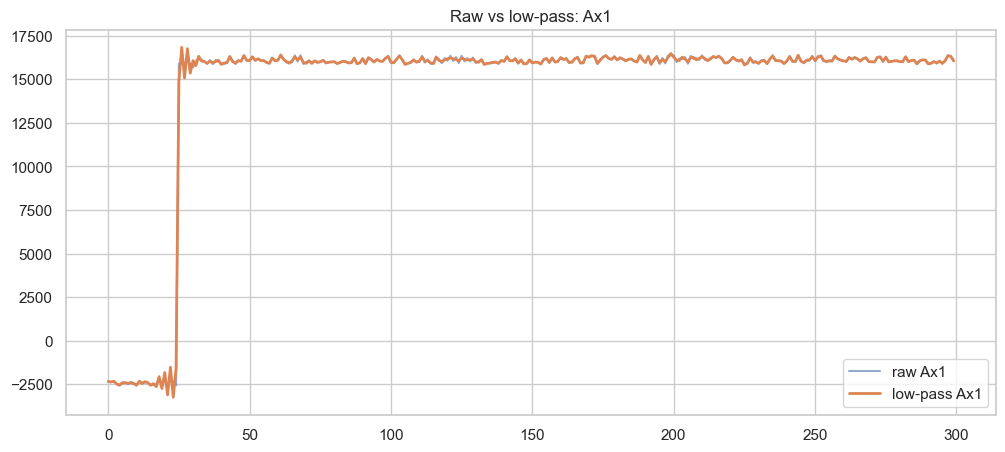

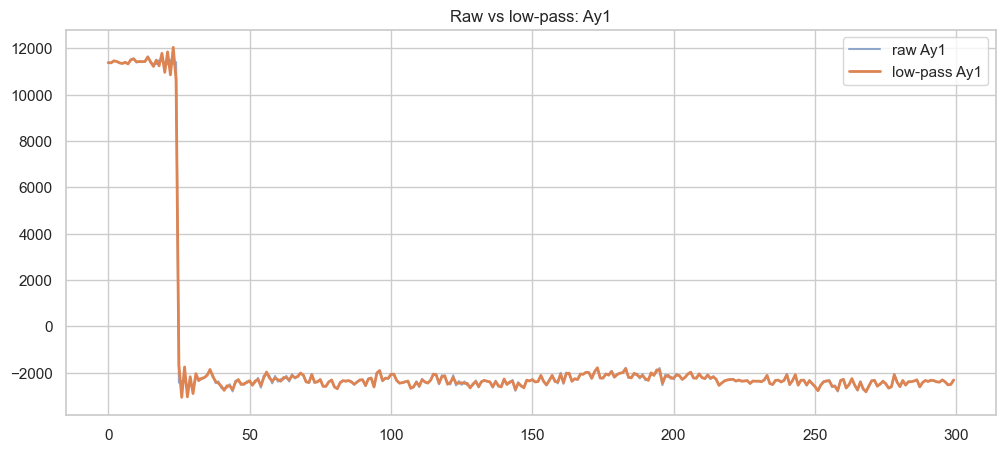

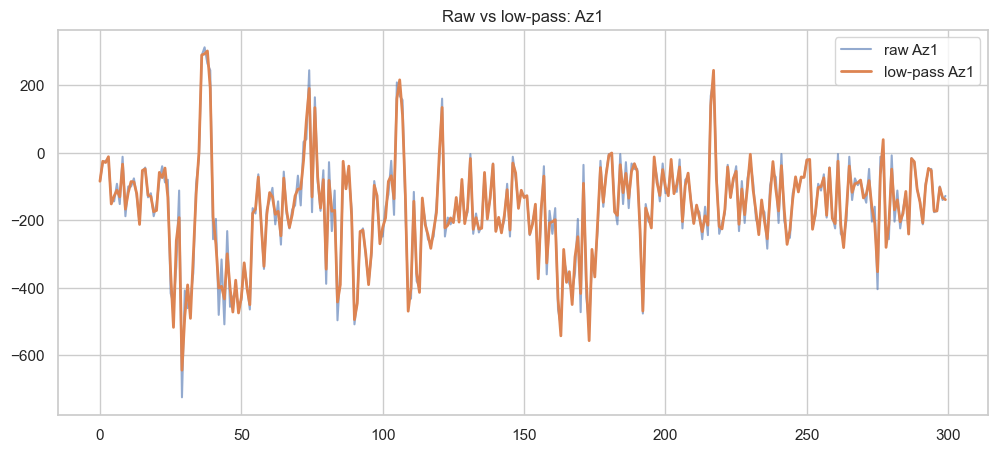

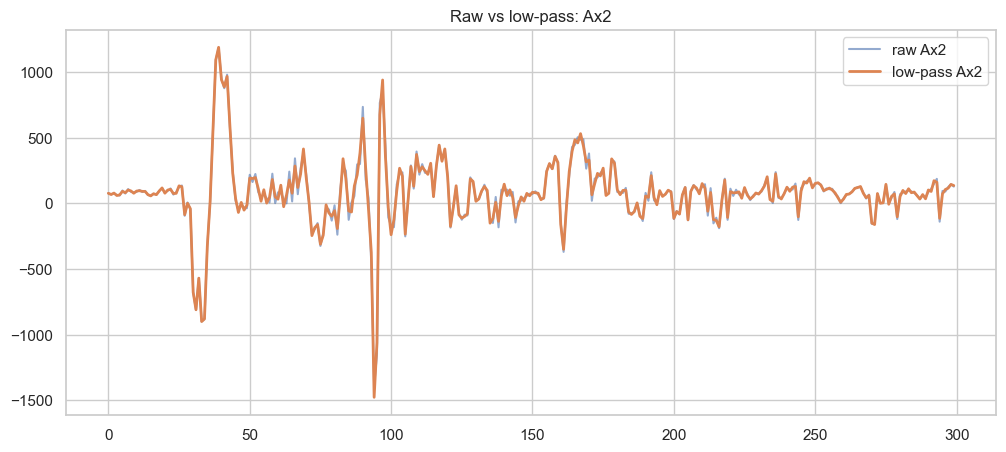

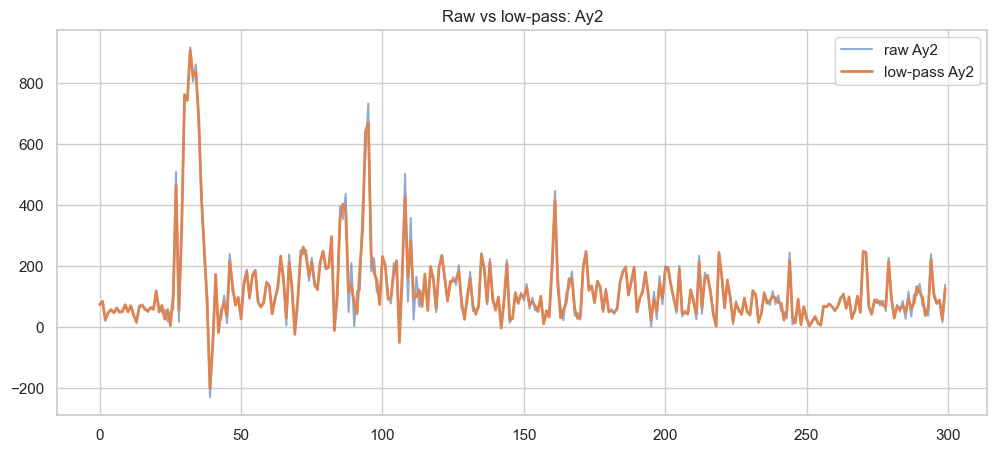

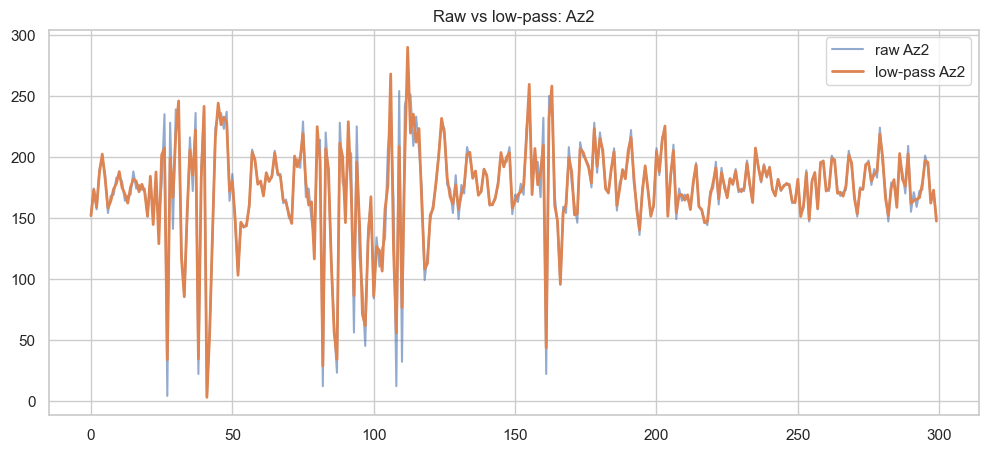

In [12]:
filtered = apply_lowpass(clean, fs=SAMPLE_RATE_HZ, cutoff=LOWPASS_CUTOFF_HZ)
plot_n = min(300, len(clean))

for col in ACC_COLS:
    plt.plot(clean[col].iloc[:plot_n].to_numpy(), label=f'raw {col}', alpha=0.6)
    plt.plot(filtered[col].iloc[:plot_n].to_numpy(), label=f'low-pass {col}', linewidth=2)
    plt.title(f'Raw vs low-pass: {col}')
    plt.legend()
    plt.show()

## Window feature preview: window 1s = 10 samples with 10 Hz data

Feature dataset shape: (4557, 181)


,label,Ax1_mean,Ax1_std,Ax1_min,Ax1_max,Ax1_range,Ay1_mean,Ay1_std,Ay1_min,Ay1_max,...,pitch_diff_mean_only,pitch_diff_std_only,roll_diff_mean_only,roll_diff_std_only,s1_jerk_mag_mean_custom,s1_jerk_mag_std_custom,s1_jerk_mag_max_custom,s2_jerk_mag_mean_custom,s2_jerk_mag_std_custom,s2_jerk_mag_max_custom
0,0,-2417.479357,63.643017,-2555.969787,-2329.488680,226.481106,11412.851392,67.479769,11323.549081,11540.118222,...,0.621364,0.073441,1.259441,0.093313,113.271036,59.392868,209.893768,28.152424,16.172560,63.555181
1,0,-2453.789145,180.513541,-2740.241425,-2055.894281,684.347145,11446.532147,155.661977,11216.820096,11782.032501,...,0.642230,0.084498,1.278643,0.079319,324.547539,229.520997,872.407248,26.792884,11.237054,54.198548
2,0,6768.210313,9053.469232,-3244.954899,16839.203306,20084.158205,4460.052975,6832.207666,-3070.107484,12043.233176,...,-0.301160,0.989726,-0.614332,1.850791,3794.803207,5589.331533,20532.729111,171.809203,151.920468,452.427055
3,0,16029.187814,130.847785,15782.759004,16321.515431,538.756428,-2279.083447,266.860827,-2909.710105,-1867.047303,...,-1.450175,0.898599,-2.641024,0.716377,439.969341,298.876996,1035.207496,414.681317,206.931815,775.134814
4,0,16057.663955,155.406691,15853.517859,16357.057568,503.539709,-2542.054750,136.358000,-2769.718643,-2300.718512,...,-0.813690,0.698516,-2.118122,0.499791,303.154252,79.316053,466.361745,228.379583,110.758048,394.762304


label
0    827
1    770
2    847
3    527
4    820
5    766
Name: count, dtype: int64

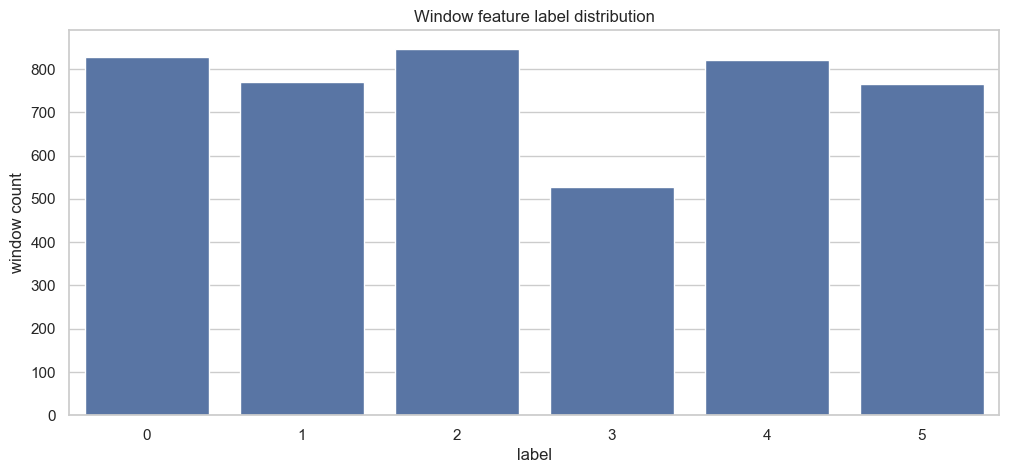

In [13]:
features = extract_window_features(filtered, window_size=WINDOW_SIZE, step=WINDOW_STEP)
print('Feature dataset shape:', features.shape)
display(features.head())

feature_label_counts = features[LABEL_COL].value_counts().sort_index()
display(feature_label_counts)

sns.barplot(x=feature_label_counts.index.astype(str), y=feature_label_counts.values)
plt.title('Window feature label distribution')
plt.xlabel('label')
plt.ylabel('window count')
plt.show()